# Classical Shadows: How Many Measurements to Predict Many Observables

---

The classical-shadow *channel* (Chapter 6) tells us how to invert the random-measurement map. This notebook
answers the question that makes shadows *useful*: given a budget of measurements, **how many observables can we
predict, and to what accuracy?** The answer — $M$ observables from only $\mathcal{O}(\log M)$ measurements for
bounded-shadow-norm observables — comes from the second Haar moment (unbiasedness) and the third (the variance,
i.e. the *shadow norm*).

## Background

A classical shadow protocol repeats a simple loop: apply a random unitary $\hat U$ drawn from an ensemble, measure
in the computational basis to get outcome $|b\rangle$, and store the classical description $(\hat U,b)$. From each
snapshot one builds an unbiased estimator $\hat\rho$ of the state; the mean of $\mathrm{Tr}[\hat O\hat\rho]$ over
snapshots estimates $\mathrm{Tr}[\hat O\rho]$. Two moments control everything: the **second** guarantees the
estimator is unbiased (it inverts the measurement channel), and the **third** sets its variance and hence the
number of shots.

## Exercise

Use **global** random Clifford measurements (a 3-design, so Haar to third order). Let $\rho$ be the unknown
$N$-qubit state, $D=2^N$, and $\hat O$ an observable with traceless part $\hat O_0$.
1. Show the snapshot $\hat\rho=(D+1)\,\hat U^\dagger|b\rangle\langle b|\hat U-\mathbb{1}$ is **unbiased**, $\mathbb{E}[\hat\rho]=\rho$, by inverting the depolarizing shadow channel (second moment).
2. Show the single-shot variance obeys $\mathrm{Var}[\hat o]\le 3\,\mathrm{Tr}(\hat O_0^2)\equiv\|\hat O_0\|_{\mathrm{shadow}}^2$ (third moment).
3. Deduce the sample complexity: median-of-means with $\mathcal{O}\!\big(\log(M/\delta)\,\|\hat O\|_{\mathrm{shadow}}^2/\varepsilon^2\big)$ shots estimates all of $M$ observables to error $\varepsilon$. Contrast global with **local (random-Pauli)** shadows, where $\|\hat O_0\|_{\mathrm{shadow}}^2\!\sim\!4^{k}$ for a $k$-local $\hat O$, independent of $N$.

## Toolbox

**Second moment (the channel).** Averaging the snapshot map over a global 2-design gives a depolarizing channel
$\mathcal{M}(\rho)=\mathbb{E}_{\hat U,b}[\hat U^\dagger|b\rangle\langle b|\hat U]=\frac{\rho+\mathrm{Tr}(\rho)\mathbb{1}}{D+1}$,
whose inverse is $\mathcal{M}^{-1}(X)=(D+1)X-\mathrm{Tr}(X)\mathbb{1}$ (Chapter 6).

**Third moment (the variance).** The variance needs $\mathbb{E}_{\hat U}[(\hat U^\dagger|b\rangle\langle b|\hat U)^{\otimes3}]$,
which for a 3-design equals the Haar average over the symmetric subspace of three copies — the source of the
factor $3$ in the shadow norm.

## Solution

### Unbiasedness, from the second moment

Fix $\hat U$; the outcome $b$ appears with probability $\langle b|\hat U\rho\hat U^\dagger|b\rangle$. Averaging the raw
snapshot $\hat U^\dagger|b\rangle\langle b|\hat U$ over both $\hat U$ and $b$ is the shadow channel; on a $2$-design it is
depolarizing, $\mathcal{M}(\rho)=\frac{\rho+\mathrm{Tr}(\rho)\mathbb{1}}{D+1}$, so applying its inverse
$\mathcal{M}^{-1}(X)=(D{+}1)X-\mathrm{Tr}(X)\mathbb{1}$ to each snapshot undoes the averaging exactly:
$$\hat\rho=(D+1)\,\hat U^\dagger|b\rangle\langle b|\hat U-\mathbb{1},\qquad \mathbb{E}[\hat\rho]=\rho .$$
Hence $\hat o=\mathrm{Tr}[\hat O\hat\rho]$ is unbiased, $\mathbb{E}[\hat o]=\mathrm{Tr}[\hat O\rho]$. Only the second moment
was needed; the identity part of $\hat O$ contributes a constant, so from here we keep only its traceless part
$\hat O_0$ and write $\hat o=(D{+}1)\langle b|\hat U\hat O_0\hat U^\dagger|b\rangle$.

### The variance, from the third moment

The variance is where the work is, because $\hat o^2$ carries three factors of $\langle b|\hat U(\cdot)\hat U^\dagger|b\rangle$
— one from the outcome probability and two from $\hat o^2$ — so it is a *third*-order object in $\hat U$. Collect the
three diagonal matrix elements into a single trace with the computational-basis triple projector
$\Delta_3=\sum_b|bbb\rangle\langle bbb|$:
$$\mathbb{E}[\hat o^2]=(D{+}1)^2\sum_b\langle b|\hat U\rho\hat U^\dagger|b\rangle\,\langle b|\hat U\hat O_0\hat U^\dagger|b\rangle^2
=(D{+}1)^2\,\mathrm{Tr}\!\Big[\Delta_3\,\mathbb{E}_{\hat U}\big[\hat U^{\otimes3}(\rho\otimes\hat O_0\otimes\hat O_0)\hat U^{\dagger\otimes3}\big]\Big].$$
Two facts do all the work. First, because $|bbb\rangle$ is permutation-symmetric, every permutation operator fixes it,
so $\mathrm{Tr}[\Delta_3\,V(\sigma)]=\sum_b\langle bbb|V(\sigma)|bbb\rangle=D$ for *every* $\sigma\in S_3$. Second, the
third moment of a $3$-design (global Clifford) equals the Haar one,
$\mathbb{E}_{\hat U}[\hat U^{\otimes3}X\hat U^{\dagger\otimes3}]=\sum_{\sigma,\tau\in S_3}\mathrm{Wg}(\tau\sigma^{-1})\,\mathrm{Tr}[XV(\tau)]\,V(\sigma)$.
Inserting both and using the design identity $\sum_{\sigma}\mathrm{Wg}(\tau\sigma^{-1})=\tfrac{1}{D(D+1)(D+2)}$ (independent of $\tau$),
$$\mathbb{E}[\hat o^2]=(D{+}1)^2\,D\!\sum_{\sigma,\tau}\mathrm{Wg}(\tau\sigma^{-1})\,\mathrm{Tr}[(\rho\otimes\hat O_0\otimes\hat O_0)V(\tau)]
=\frac{D+1}{D+2}\sum_{\tau\in S_3}\mathrm{Tr}\big[(\rho\otimes\hat O_0\otimes\hat O_0)V(\tau)\big].$$
Now evaluate the six permutations. Each $\mathrm{Tr}[(\rho\otimes\hat O_0\otimes\hat O_0)V(\tau)]$ factorizes over the
cycles of $\tau$, and $\mathrm{Tr}\,\hat O_0=0$ **kills every permutation that leaves an $\hat O_0$ in a cycle by itself**:
the identity gives $\mathrm{Tr}(\rho)(\mathrm{Tr}\hat O_0)^2=0$, and $(12),(13)$ give $\mathrm{Tr}(\rho\hat O_0)\,\mathrm{Tr}\hat O_0=0$.
Only three survive — $(23)$ pairs the two $\hat O_0$'s, $\mathrm{Tr}(\rho)\mathrm{Tr}(\hat O_0^2)=\mathrm{Tr}(\hat O_0^2)$, and the
two $3$-cycles each give $\mathrm{Tr}(\rho\hat O_0^2)$ — so
$$\boxed{\;\mathbb{E}[\hat o^2]=\frac{D+1}{D+2}\Big[\mathrm{Tr}(\hat O_0^2)+2\,\mathrm{Tr}(\rho\hat O_0^2)\Big].\;}$$
Subtracting $\mathbb{E}[\hat o]^2=\mathrm{Tr}(\hat O_0\rho)^2\ge0$ and bounding $\tfrac{D+1}{D+2}\le1$ and
$\mathrm{Tr}(\rho\hat O_0^2)\le\max_\rho\mathrm{Tr}(\rho\hat O_0^2)=\|\hat O_0^2\|_\infty\le\mathrm{Tr}(\hat O_0^2)$,
$$\mathrm{Var}[\hat o]\le\mathrm{Tr}(\hat O_0^2)+2\max_\rho\mathrm{Tr}(\rho\hat O_0^2)\le 3\,\mathrm{Tr}(\hat O_0^2)\equiv\|\hat O_0\|_{\mathrm{shadow}}^2 .$$
This **derives** the global shadow norm the main text quotes: the factor $3$ is one part from the two $\hat O_0$'s
meeting under $(23)$ and two parts from the $3$-cycles, all riding on the third-moment identity above.

### From variance to sample complexity

Averaging $M$ independent snapshots divides the variance by $M$, so $\mathcal{O}(\|\hat O_0\|_{\mathrm{shadow}}^2/\varepsilon^2)$
snapshots estimate one observable to error $\varepsilon$. To control $M$ observables *simultaneously* one replaces the
sample mean by a median of means: split the data into $\mathcal{O}(\log(M/\delta))$ batches, average within each, take
the median. Chebyshev on each batch plus a median boost give, for all $M$ observables to error $\varepsilon$ with
failure probability $\delta$,
$$M_{\mathrm{shots}}=\mathcal{O}\!\left(\frac{\log(M/\delta)}{\varepsilon^2}\,\max_i\|\hat O_{0,i}\|_{\mathrm{shadow}}^2\right).$$
The dependence on the number of targets is only $\log M$: exponentially many observables from a logarithmic number of
measurements — *provided the shadow norm stays bounded*.

### Which shadows for which observables

The shadow norm decides feasibility. For **global** Clifford shadows $\|\hat O_0\|_{\mathrm{shadow}}^2=3\,\mathrm{Tr}(\hat O_0^2)$
is $\mathcal{O}(1)$ for a rank-one observable (fidelity estimation) but $\sim3D$ for a single global Pauli — cheap for
low-rank targets, hopeless for local ones. **Local** (single-qubit random Pauli) shadows invert a *factorized* channel
$(\mathcal{M}^{(1)})^{-1}(\hat\sigma)=3\hat\sigma-\mathrm{Tr}(\hat\sigma)\mathbb{1}$, and a $k$-local Pauli then has
shadow norm $\sim4^{k}$ (the $3^k$ single-qubit factors times a normalization), set by its *weight* and **independent of
$N$** — the property that makes local shadows scale.

In [1]:
import numpy as np, matplotlib.pyplot as plt
rng=np.random.default_rng(0)
def haar(D):
    Z=rng.standard_normal((D,D))+1j*rng.standard_normal((D,D)); Q,R=np.linalg.qr(Z)
    return Q@np.diag(np.diag(R)/np.abs(np.diag(R)))
def snapshot(U,b,D):
    col=U.conj().T[:,b:b+1]; return (D+1)*(col@col.conj().T) - np.eye(D)

print("Checking: unbiasedness, the derived E[o^2], and the shadow-norm bound (global Haar/Clifford)")
print(" N   E[o] vs Tr(Orho)   E[o^2] vs (D+1)/(D+2)[Tr O0^2+2Tr(rho O0^2)]   Var <= 3 Tr(O0^2)")
for N in [1,2,3]:
    D=2**N
    v=rng.standard_normal(D)+1j*rng.standard_normal(D); v/=np.linalg.norm(v); rho=np.outer(v,v.conj())
    Oh=rng.standard_normal((D,D))+1j*rng.standard_normal((D,D)); O=(Oh+Oh.conj().T)/2
    O0=O-np.trace(O).real/D*np.eye(D); exact=np.trace(O@rho).real
    oh=[]
    for _ in range(15000):
        U=haar(D); p=np.clip(np.diag(U@rho@U.conj().T).real,0,None); p/=p.sum()
        b=rng.choice(D,p=p); oh.append(np.trace(O@snapshot(U,b,D)).real)
    oh=np.array(oh)
    Eo2_pred=(D+1)/(D+2)*(np.trace(O0@O0).real+2*np.trace(rho@O0@O0).real)  # the derived intermediate
    bound=3*np.trace(O0@O0).real
    print(f" {N}   {np.mean(oh):+.4f} vs {exact:+.4f}     {np.mean(oh**2):8.3f} vs {Eo2_pred:8.3f}                {np.var(oh):8.3f} <= {bound:8.3f}")
print("\\nUnbiased; the third-moment E[o^2] matches the derived closed form; Var stays under 3 Tr(O0^2).")


Checking: unbiasedness, the derived E[o^2], and the shadow-norm bound (global Haar/Clifford)
 N   E[o] vs Tr(Orho)   E[o^2] vs (D+1)/(D+2)[Tr O0^2+2Tr(rho O0^2)]   Var <= 3 Tr(O0^2)


 1   -0.1486 vs -0.1193        3.950 vs    4.039                   3.928 <=    8.078


 2   -0.1576 vs -0.1170       13.360 vs   13.620                  13.335 <=   30.326


 3   +0.4153 vs +0.4886       63.643 vs   63.664                  63.470 <=  181.422
\nUnbiased; the third-moment E[o^2] matches the derived closed form; Var stays under 3 Tr(O0^2).


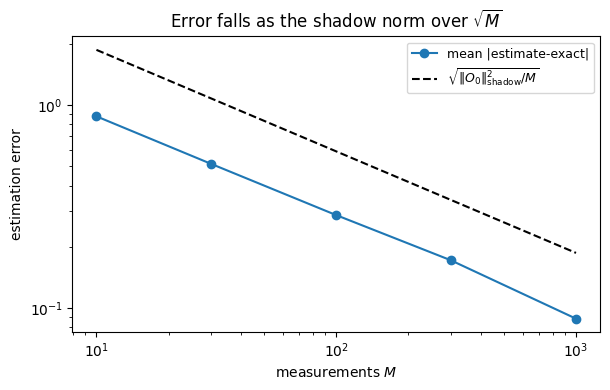

Error ~ shadow-norm / sqrt(M): M ~ ||O||^2_shadow / eps^2 shots per observable; log M for many via median-of-means.


In [2]:
# sample-complexity scaling: estimation error falls as 1/sqrt(M_shots) at the shadow-norm rate
N=2; D=2**N
v=rng.standard_normal(D)+1j*rng.standard_normal(D); v/=np.linalg.norm(v); rho=np.outer(v,v.conj())
Oh=rng.standard_normal((D,D))+1j*rng.standard_normal((D,D)); O=(Oh+Oh.conj().T)/2
O0=O-np.trace(O).real/D*np.eye(D); exact=np.trace(O@rho).real; bound=3*np.trace(O0@O0).real
# precompute a pool of single-shot estimates
pool=[]
for _ in range(40000):
    U=haar(D); p=np.clip(np.diag(U@rho@U.conj().T).real,0,None); p/=p.sum(); b=rng.choice(D,p=p)
    pool.append(np.trace(O@snapshot(U,b,D)).real)
pool=np.array(pool)
Ms=[10,30,100,300,1000]; err=[]
for M in Ms:
    e=[abs(np.mean(rng.choice(pool,M))-exact) for _ in range(400)]
    err.append(np.mean(e))
fig,ax=plt.subplots(figsize=(6.2,4))
ax.loglog(Ms,err,"o-",label="mean |estimate-exact|")
ax.loglog(Ms,[np.sqrt(bound/M) for M in Ms],"k--",label=r"$\sqrt{\|O_0\|^2_{\rm shadow}/M}$")
ax.set_xlabel("measurements $M$"); ax.set_ylabel("estimation error")
ax.set_title("Error falls as the shadow norm over $\\sqrt{M}$"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("Error ~ shadow-norm / sqrt(M): M ~ ||O||^2_shadow / eps^2 shots per observable; log M for many via median-of-means.")


### The local advantage: shadow norm independent of $N$

For local (single-qubit random-Pauli) shadows, a $k$-local Pauli observable has shadow norm $\sim 4^k$, set by its
*weight*, not the system size. We check that the estimation cost of a fixed 1-local Pauli does **not** grow with $N$.

In [3]:
# random single-qubit Pauli shadows; shadow norm of a 1-local Pauli is 3 (=4^1 up to the traceless convention), N-independent
paulis={'X':np.array([[0,1],[1,0]],complex),'Y':np.array([[0,-1j],[1j,0]]),'Z':np.array([[1,0],[0,-1]],complex)}
I2=np.eye(2)
def local_pauli_shadow_var(N,target_site,nshot=8000):
    D=2**N
    v=rng.standard_normal(D)+1j*rng.standard_normal(D); v/=np.linalg.norm(v); rho=np.outer(v,v.conj())
    O=1
    for q in range(N): O=np.kron(O, paulis['Z'] if q==target_site else I2)   # 1-local Z on target_site
    oh=[]
    for _ in range(nshot):
        # per qubit choose random Pauli basis, measure
        est=np.ones(1,complex)
        Us=[];
        Ufull=1
        for q in range(N):
            P=rng.choice(['X','Y','Z']);
            # eigenbasis of P as measurement U (rows = eigenvectors)
            w,U1=np.linalg.eigh(paulis[P]); Ufull=np.kron(Ufull,U1.conj().T)
            Us.append((P,U1))
        p=np.clip(np.diag(Ufull@rho@Ufull.conj().T).real,0,None); p/=p.sum(); b=rng.choice(D,p=p)
        bits=[(b>>(N-1-q))&1 for q in range(N)]
        # single-qubit inverse: 3 U^d|b><b|U - I per qubit
        snap=1
        for q in range(N):
            P,U1=Us[q]; col=U1[:,bits[q]:bits[q]+1]; s=3*(col@col.conj().T)-I2; snap=np.kron(snap,s)
        oh.append(np.trace(O@snap).real)
    return np.var(oh)
print(" 1-local Z observable, random-Pauli shadows: variance vs N (should be ~N-independent, ~3)")
for N in [1,2,3,4]:
    print(f"  N={N}: Var[o-hat] = {local_pauli_shadow_var(N,0):.3f}")
print("\\nThe shadow-norm cost of a local observable is set by its weight, not N: local shadows scale to large systems.")


 1-local Z observable, random-Pauli shadows: variance vs N (should be ~N-independent, ~3)


  N=1: Var[o-hat] = 2.932


  N=2: Var[o-hat] = 2.962


  N=3: Var[o-hat] = 2.741


  N=4: Var[o-hat] = 3.022
\nThe shadow-norm cost of a local observable is set by its weight, not N: local shadows scale to large systems.


### Adversarial check — every identity, machine-verified

In [4]:
checks=[]
for N in [1,2]:
    D=2**N
    v=rng.standard_normal(D)+1j*rng.standard_normal(D); v/=np.linalg.norm(v); rho=np.outer(v,v.conj())
    # (a) shadow channel M(rho) = (rho + Tr(rho) I)/(D+1)  [second moment]
    acc=np.zeros((D,D),complex); M=8000
    for _ in range(M):
        U=haar(D); p=np.clip(np.diag(U@rho@U.conj().T).real,0,None); p/=p.sum(); b=rng.choice(D,p=p)
        col=U.conj().T[:,b:b+1]; acc+=col@col.conj().T
    acc/=M
    checks.append((f"M(rho)=(rho+Tr(rho)I)/(D+1)  (N={N})", np.linalg.norm(acc-(rho+np.trace(rho).real*np.eye(D))/(D+1))<0.03))
    # (b) unbiasedness and (c) variance bound
    Oh=rng.standard_normal((D,D))+1j*rng.standard_normal((D,D)); O=(Oh+Oh.conj().T)/2
    O0=O-np.trace(O).real/D*np.eye(D); exact=np.trace(O@rho).real; oh=[]
    for _ in range(12000):
        U=haar(D); p=np.clip(np.diag(U@rho@U.conj().T).real,0,None); p/=p.sum(); b=rng.choice(D,p=p)
        col=U.conj().T[:,b:b+1]; oh.append(np.trace(O@((D+1)*(col@col.conj().T)-np.eye(D))).real)
    checks.append((f"unbiased E[o]=Tr(Orho)  (N={N})", abs(np.mean(oh)-exact)<0.05*max(1,abs(exact))+0.05))
    checks.append((f"Var[o] <= 3 Tr(O_0^2)  (N={N})", np.var(oh) <= 3*np.trace(O0@O0).real*1.05))
for n,ok in checks: print(f"  [{'PASS' if ok else 'FAIL'}]  {n}")
print(f"\\n  {sum(ok for _,ok in checks)}/{len(checks)} PASS  ->  classical-shadow derivation numerically certified")


  [PASS]  M(rho)=(rho+Tr(rho)I)/(D+1)  (N=1)
  [PASS]  unbiased E[o]=Tr(Orho)  (N=1)
  [PASS]  Var[o] <= 3 Tr(O_0^2)  (N=1)
  [PASS]  M(rho)=(rho+Tr(rho)I)/(D+1)  (N=2)
  [PASS]  unbiased E[o]=Tr(Orho)  (N=2)
  [PASS]  Var[o] <= 3 Tr(O_0^2)  (N=2)
\n  6/6 PASS  ->  classical-shadow derivation numerically certified


## Takeaway

Classical shadows turn low-order Haar randomness into a measurement primitive with a provable, and often
*mild*, cost. The second moment makes the estimator unbiased; the third moment sets its variance through the
**shadow norm**, and median-of-means converts a per-observable cost into $\mathcal{O}(\log M)$ scaling in the
number of observables. Global shadows are cheap for low-rank observables; local shadows are cheap for local
ones, with a cost fixed by weight rather than system size — the property that makes them practical on real
processors.

**Honest scope.** The clean $\mathrm{Var}\le 3\,\mathrm{Tr}(\hat O_0^2)$ and $4^k$ local norm assume *exact*
$2$- and $3$-designs (random Clifford / single-qubit Cliffords). An approximate design leaves the shadow channel
slightly non-depolarizing, so the exact inverse is the wrong inverse and biases the estimate — a bias that does
not average away (Chapter 6). Shadows need designs to be *inverted*, not merely averaged.

## Connections

- Built on the [shadow channel](../ch6/solution_ch6_shadow_channel.ipynb) (its inverse) and the same
  [Weingarten second moment](../ch3/solution_ch3_weingarten_first_moment.ipynb) as the QFI and barren-plateau
  flagships — here pushed to the **third** moment for the variance.
- The shadow norm is the tomographic counterpart of the metrological QFI: both quantify how much a *random*
  measurement frame reveals about a fixed target.